<a href="https://colab.research.google.com/github/ArielaMishaanCohen/ProyectoVC/blob/main/ProyectoVC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final
Visión por Computadora  
Alina Carías, Daniel Machic, Ignacio Méndez, Ariela Mishaan y Diego Soto

- **DFL - Bundesliga Data Shootout**: https://www.kaggle.com/competitions/dfl-bundesliga-data-shootout

- **Github:** https://github.com/ArielaMishaanCohen/ProyectoVC.git

## Importaciones

In [ ]:
!pip install datasets opencv-python pandas numpy matplotlib

In [ ]:
!pip install -q kaggle datasets opencv-python

In [ ]:
from google.colab import files
files.upload()  # sube kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username": "Disoto12",\r\n  "key": "KGAT_b75abeb30bac9773d16c35b5a66fcf34"\r\n}'}

In [ ]:
import os, shutil

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 600)

In [ ]:
!mkdir -p /content/data/kaggle

!kaggle datasets download -d saberghaderi/-dfl-bundesliga-460-mp4-videos-in-30sec-csv \
  -p /content/data/kaggle \
  --unzip

Dataset URL: https://www.kaggle.com/datasets/saberghaderi/-dfl-bundesliga-460-mp4-videos-in-30sec-csv
License(s): CC-BY-SA-4.0
100% 10.1G/10.1G [01:38<00:00, 110MB/s]



In [ ]:
import os

ruta_kaggle = "/content/data/kaggle"

for root, dirs, files in os.walk(ruta_kaggle):
    print(root, len(files))
    print(files[:5])

/content/data/kaggle 0
[]
/content/data/kaggle/DFL Bundesliga Data Shootout 0
[]
/content/data/kaggle/DFL Bundesliga Data Shootout/test 36
['test (21).mp4', 'test (19).mp4', 'test (23).mp4', 'test (1).mp4', 'test.csv']
/content/data/kaggle/DFL Bundesliga Data Shootout/train 1
['train.csv']
/content/data/kaggle/DFL Bundesliga Data Shootout/train/B1606b0e6_1 92
['B1606b0e6_1 (40).mp4', 'B1606b0e6_1 (92).mp4', 'B1606b0e6_1 (82).mp4', 'B1606b0e6_1 (41).mp4', 'B1606b0e6_1 (28).mp4']
/content/data/kaggle/DFL Bundesliga Data Shootout/train/D35bd9041_1 93
['D35bd9041_1 (9).mp4', 'D35bd9041_1 (67).mp4', 'D35bd9041_1 (74).mp4', 'D35bd9041_1 (15).mp4', 'D35bd9041_1 (34).mp4']
/content/data/kaggle/DFL Bundesliga Data Shootout/train/A1606b0e6_0 76
['A1606b0e6_0 (41).mp4', 'A1606b0e6_0 (1).mp4', 'A1606b0e6_0 (56).mp4', 'A1606b0e6_0 (37).mp4', 'A1606b0e6_0 (69).mp4']
/content/data/kaggle/DFL Bundesliga Data Shootout/train/C35bd9041_0 83
['C35bd9041_0 (43).mp4', 'C35bd9041_0 (41).mp4', 'C35bd9041_0 (3

In [ ]:
import pandas as pd
import glob

csv_files = glob.glob("/content/data/kaggle/**/*.csv", recursive=True)
print(csv_files)

df_kaggle = pd.read_csv(csv_files[0])
df_kaggle.head()

['/content/data/kaggle/DFL Bundesliga Data Shootout/test/test.csv', '/content/data/kaggle/DFL Bundesliga Data Shootout/train/train.csv']


,Name,Folder Path
0,test (1).mp4,test
1,test (10).mp4,test
2,test (11).mp4,test
3,test (12).mp4,test
4,test (13).mp4,test


In [ ]:
video_files = glob.glob("/content/data/kaggle/**/*.mp4", recursive=True)

print("Cantidad de videos:", len(video_files))
print(video_files[:5])

Cantidad de videos: 460
['/content/data/kaggle/DFL Bundesliga Data Shootout/test/test (21).mp4', '/content/data/kaggle/DFL Bundesliga Data Shootout/test/test (19).mp4', '/content/data/kaggle/DFL Bundesliga Data Shootout/test/test (23).mp4', '/content/data/kaggle/DFL Bundesliga Data Shootout/test/test (1).mp4', '/content/data/kaggle/DFL Bundesliga Data Shootout/test/test (34).mp4']


In [ ]:
import cv2

video_path = video_files[0]

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duracion = frames / fps

print("FPS:", fps)
print("Frames:", frames)
print("Duración segundos:", duracion)

ret, frame = cap.read()
cap.release()

print(frame.shape)

FPS: 25.0
Frames: 750
Duración segundos: 30.0
(1080, 1920, 3)


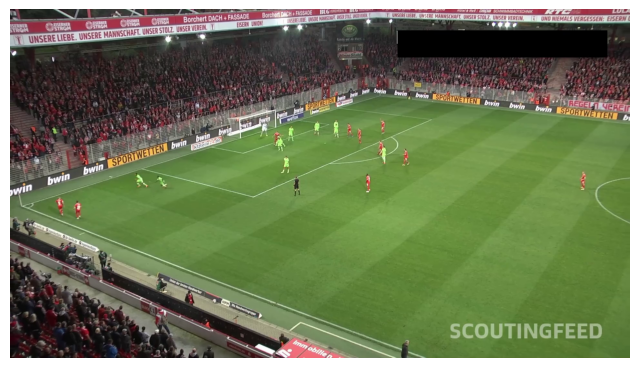

In [ ]:
import matplotlib.pyplot as plt

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,5))
plt.imshow(frame_rgb)
plt.axis("off")
plt.show()

## Hugging Face

In [ ]:
!pip install -q datasets

In [ ]:
from datasets import load_dataset

dataset_hf = load_dataset("dbal0503/Bundesliga")
dataset_hf

Repo card metadata block was not found. Setting CardData to empty.


DatasetDict({
    train: Dataset({
        features: ['video_id', 'time', 'event', 'event_attributes'],
        num_rows: 11218
    })
})

In [ ]:
df_hf = dataset_hf["train"].to_pandas()
df_hf.head()

,video_id,time,event,event_attributes
0,1606b0e6_0,200.265822,start,None
1,1606b0e6_0,201.150000,challenge,['ball_action_forced']
2,1606b0e6_0,202.765822,end,None
3,1606b0e6_0,210.124111,start,None
4,1606b0e6_0,210.870000,challenge,['opponent_dispossessed']


In [ ]:
import cv2
import os

def extraer_frames(video_path, output_dir, cada_n_frames=30):
    os.makedirs(output_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    frame_id = 0
    saved_id = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        if frame_id % cada_n_frames == 0:
            nombre = f"frame_{saved_id:05d}.jpg"
            cv2.imwrite(os.path.join(output_dir, nombre), frame)
            saved_id += 1

        frame_id += 1

    cap.release()
    return saved_id

In [ ]:
output_dir = "/content/frames/video_001"

cantidad = extraer_frames(video_files[0], output_dir, cada_n_frames=30)

print("Frames guardados:", cantidad)

Frames guardados: 25
